This python code is for an application of the NEMO (NEighborhood based Multi-Omics clustering) multi-omics analysis of partially measured data, implemented by Wenyan Luo. 

Reference:
Nimrod Rappoport, Ron Shamir, NEMO: cancer subtyping by integration of partial multi-omic data, Bioinformatics, Volume 35, Issue 18, September 2019, Pages 3348–3356, https://doi.org/10.1093/bioinformatics/btz058

In [18]:
# Follow the EDA by Almed Tohamy
import pandas as pd
# Load three files into pandas
rppa_raw = None
rna_raw  = None
clin_raw = None 

for fn in ['mrna_seq_v2_rsem', 'rppa', 'clinical_patient']:
    if fn == "rppa":
        rppa_raw = pd.read_csv(f'../glioblastoma/gbm_tcga_pan_can_atlas_2018/data_{fn}.txt', sep='\t', index_col = 0) 
        print("Shape of RPPA:", rppa_raw.shape)
    if fn == "mrna_seq_v2_rsem":
        rna_raw = pd.read_csv(f'../glioblastoma/gbm_tcga_pan_can_atlas_2018/data_{fn}.txt', sep='\t',low_memory=False)
        print("Shape of RNA-Seq:", rna_raw.shape)
    if fn == "clinical_patient":
        clin_raw = pd.read_csv(f'../glioblastoma/gbm_tcga_pan_can_atlas_2018/data_{fn}.txt', sep='\t', comment="#")
        print('Shape of clinical_patient is:', clin_raw.shape)

Shape of RNA-Seq: (20531, 162)
Shape of RPPA: (198, 231)
Shape of clinical_patient is: (585, 38)


In [19]:
rppa_raw.head()

,TCGA-02-0011-01,TCGA-08-0345-01,TCGA-08-0353-01,TCGA-19-1386-01,TCGA-15-1447-01,TCGA-06-0879-01,TCGA-12-0692-01,TCGA-12-1597-01,TCGA-28-1753-01,TCGA-02-0014-01,...,TCGA-19-A60I-01,TCGA-RR-A6KA-01,TCGA-06-A5U0-01,TCGA-19-A6J5-01,TCGA-19-A6J4-01,TCGA-RR-A6KB-01,TCGA-06-A5U1-01,TCGA-06-A7TL-01,TCGA-06-A6S1-01,TCGA-06-A6S0-01
Composite.Element.REF,,,,,,,,,,,,,,,,,,,,,
YWHAE|14-3-3_epsilon,-0.207613,-0.636009,-0.614822,-0.814021,-0.404739,-0.683170,-0.368914,-0.630628,-0.261479,-0.497308,...,-0.931323,-0.562675,-0.658759,-0.663650,-0.514397,-0.062952,-0.732799,-0.551528,-0.552643,-0.666786
EIF4EBP1|4E-BP1,0.656279,-0.110116,0.795610,-0.122043,0.021175,-0.039455,0.148736,0.195686,0.735037,0.574000,...,0.559416,0.624413,-0.387927,0.840756,-0.248578,-0.683082,-0.462129,-0.122321,-0.288098,-0.147660
EIF4EBP1|4E-BP1_pS65,0.543074,0.303296,0.505316,0.549720,0.256577,0.292693,-0.019744,0.625297,0.276694,1.229849,...,0.513167,1.000278,0.499328,0.086153,0.328906,0.860816,0.300206,0.550100,0.238205,0.621720
EIF4EBP1|4E-BP1_pT37T46,1.895562,1.675490,1.811415,2.560177,0.663294,1.912979,1.275898,3.005867,3.398537,3.221768,...,1.765561,1.991205,1.826416,1.731022,1.030846,0.841961,1.207399,1.814400,1.349579,1.131411
TP53BP1|53BP1,1.089430,2.234210,1.827349,2.022301,1.709573,1.926509,0.986573,2.223983,1.742230,2.112393,...,2.507641,-0.120784,2.327586,1.551078,1.976395,1.688886,1.494165,3.101044,2.916305,1.864738


In [20]:
rna_raw.head()

,Hugo_Symbol,Entrez_Gene_Id,TCGA-02-0047-01,TCGA-02-0055-01,TCGA-02-2483-01,TCGA-02-2485-01,TCGA-02-2486-01,TCGA-06-0125-01,TCGA-06-0125-02,TCGA-06-0129-01,...,TCGA-41-3915-01,TCGA-41-4097-01,TCGA-41-5651-01,TCGA-76-4925-01,TCGA-76-4926-01,TCGA-76-4927-01,TCGA-76-4928-01,TCGA-76-4929-01,TCGA-76-4931-01,TCGA-76-4932-01
0,NaN,100130426,0.0000,0.0000,0.0000,0.0000,0.0000,0.4604,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,NaN,100133144,3.0732,0.0000,2.9467,15.9952,5.5610,9.9246,3.3758,22.3207,...,8.2279,15.2648,1.2190,12.2160,9.5716,2.4096,10.1709,8.4757,6.1600,0.0000
2,UBE2Q2P2,100134869,6.7611,15.6973,13.9398,14.9571,4.8049,11.6684,3.3862,16.8239,...,10.2174,13.8987,10.3611,17.3596,13.9689,6.4257,6.4812,3.2496,7.9576,9.9502
3,HMGB1P1,10357,54.7036,31.3945,60.3441,91.8238,62.5366,52.1491,41.6125,76.2289,...,35.5731,27.6285,70.0838,108.1350,70.5556,43.0201,42.4584,62.2278,58.8188,60.1990
4,NaN,10431,886.3210,885.7740,1234.8300,470.0000,546.3410,391.9330,419.2460,642.3830,...,512.5160,593.2460,507.6950,531.9330,588.0410,620.8840,533.7420,668.9000,458.3530,499.5020


In [21]:
clin_raw.head()

,PATIENT_ID,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,...,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL
0,TCGA-02-2466,NaN,GBM,c4171de5-8dac-44bd-a6eb-174f9451dbb7,61.0,Male,NaN,NaN,511.0,-22457.0,...,No,1:DECEASED,16.799816,1:DEAD WITH TUMOR,16.799816,NaN,NaN,1:PROGRESSION,4.208173,EUR
1,TCGA-02-2470,NaN,GBM,e948d951-9299-4dec-9772-60b4ac3569cb,57.0,Male,NaN,NaN,393.0,-21021.0,...,No,1:DECEASED,12.920406,1:DEAD WITH TUMOR,12.920406,NaN,NaN,1:PROGRESSION,6.016372,EUR
2,TCGA-02-2483,GBM_IDHmut-non-codel,GBM,a2ac9937-f351-4d78-9261-264bf6c21e0c,43.0,Male,NaN,NaN,466.0,-15964.0,...,Yes,0:LIVING,15.320380,0:ALIVE OR DEAD TUMOR FREE,15.320380,NaN,NaN,0:CENSORED,15.320380,SAS_ADMIX
3,TCGA-02-2485,GBM_IDHwt,GBM,521ea765-1bd1-423d-a75d-091243df37a9,53.0,Male,NaN,NaN,470.0,-19494.0,...,Yes,0:LIVING,15.451885,0:ALIVE OR DEAD TUMOR FREE,15.451885,NaN,NaN,1:PROGRESSION,6.115001,AFR_ADMIX
4,TCGA-02-2486,GBM_IDHwt,GBM,79a68b32-29a3-47bf-9b2b-643ec7323d73,64.0,Male,NaN,NaN,493.0,-23394.0,...,Yes,1:DECEASED,20.317586,1:DEAD WITH TUMOR,20.317586,NaN,NaN,1:PROGRESSION,20.317586,EUR


In [22]:
# Clean and standardize IDs
def tcga_base_id(x):
    # keep first three parts: TCGA-XX-YYYY
    return '-'.join(x.split('-')[:3])

# Clean RPPA columns
rppa = rppa_raw.copy()
rppa.columns = [tcga_base_id(c) for c in rppa.columns]

# Clean RNA columns (skip the first two metadata columns)
rna = rna_raw.drop(columns=['Hugo_Symbol', 'Entrez_Gene_Id']).copy()
rna.columns = [tcga_base_id(c) for c in rna.columns]

# Clean clinical IDs
clin = clin_raw.copy()
clin['PATIENT_ID'] = clin['PATIENT_ID'].apply(tcga_base_id)


In [23]:
rppa.head()

,TCGA-02-0011,TCGA-08-0345,TCGA-08-0353,TCGA-19-1386,TCGA-15-1447,TCGA-06-0879,TCGA-12-0692,TCGA-12-1597,TCGA-28-1753,TCGA-02-0014,...,TCGA-19-A60I,TCGA-RR-A6KA,TCGA-06-A5U0,TCGA-19-A6J5,TCGA-19-A6J4,TCGA-RR-A6KB,TCGA-06-A5U1,TCGA-06-A7TL,TCGA-06-A6S1,TCGA-06-A6S0
Composite.Element.REF,,,,,,,,,,,,,,,,,,,,,
YWHAE|14-3-3_epsilon,-0.207613,-0.636009,-0.614822,-0.814021,-0.404739,-0.683170,-0.368914,-0.630628,-0.261479,-0.497308,...,-0.931323,-0.562675,-0.658759,-0.663650,-0.514397,-0.062952,-0.732799,-0.551528,-0.552643,-0.666786
EIF4EBP1|4E-BP1,0.656279,-0.110116,0.795610,-0.122043,0.021175,-0.039455,0.148736,0.195686,0.735037,0.574000,...,0.559416,0.624413,-0.387927,0.840756,-0.248578,-0.683082,-0.462129,-0.122321,-0.288098,-0.147660
EIF4EBP1|4E-BP1_pS65,0.543074,0.303296,0.505316,0.549720,0.256577,0.292693,-0.019744,0.625297,0.276694,1.229849,...,0.513167,1.000278,0.499328,0.086153,0.328906,0.860816,0.300206,0.550100,0.238205,0.621720
EIF4EBP1|4E-BP1_pT37T46,1.895562,1.675490,1.811415,2.560177,0.663294,1.912979,1.275898,3.005867,3.398537,3.221768,...,1.765561,1.991205,1.826416,1.731022,1.030846,0.841961,1.207399,1.814400,1.349579,1.131411
TP53BP1|53BP1,1.089430,2.234210,1.827349,2.022301,1.709573,1.926509,0.986573,2.223983,1.742230,2.112393,...,2.507641,-0.120784,2.327586,1.551078,1.976395,1.688886,1.494165,3.101044,2.916305,1.864738


In [24]:
# Remove duplicated patient IDs and take transpose for rppa and rna
rppa = rppa.loc[:, ~rppa.columns.duplicated()]
rppa = rppa.T

rna  = rna.loc[:,  ~rna.columns.duplicated()]
rna  = rna.T

clin = clin.drop_duplicates(subset='PATIENT_ID', keep='first')


In [49]:
# rppa.head()
# rna.head()
clin.head()
print(clin.columns.tolist())

['PATIENT_ID', 'SUBTYPE', 'CANCER_TYPE_ACRONYM', 'OTHER_PATIENT_ID', 'AGE', 'SEX', 'AJCC_PATHOLOGIC_TUMOR_STAGE', 'AJCC_STAGING_EDITION', 'DAYS_LAST_FOLLOWUP', 'DAYS_TO_BIRTH', 'DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS', 'ETHNICITY', 'FORM_COMPLETION_DATE', 'HISTORY_NEOADJUVANT_TRTYN', 'ICD_10', 'ICD_O_3_HISTOLOGY', 'ICD_O_3_SITE', 'INFORMED_CONSENT_VERIFIED', 'NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT', 'PATH_M_STAGE', 'PATH_N_STAGE', 'PATH_T_STAGE', 'PERSON_NEOPLASM_CANCER_STATUS', 'PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT', 'PRIOR_DX', 'RACE', 'RADIATION_THERAPY', 'WEIGHT', 'IN_PANCANPATHWAYS_FREEZE', 'OS_STATUS', 'OS_MONTHS', 'DSS_STATUS', 'DSS_MONTHS', 'DFS_STATUS', 'DFS_MONTHS', 'PFS_STATUS', 'PFS_MONTHS', 'GENETIC_ANCESTRY_LABEL']


In [26]:
# Convert everything to numeric
rppa = rppa.apply(pd.to_numeric, errors='coerce')
rna  = rna.apply(pd.to_numeric, errors='coerce')

# Drop features (columns) with >20% missing values
rppa = rppa.dropna(axis=1, thresh=int(0.8 * len(rppa)))
rna  = rna.dropna(axis=1, thresh=int(0.8 * len(rna)))

# Fill remaining NaNs with feature means
rppa = rppa.fillna(rppa.mean())
rna  = rna.fillna(rna.mean())


In [27]:
# sanity check for shape
print("The shape of rna after clearning: ", rna.shape)
print("The shape of rppa after clearning: ", rppa.shape)
print("The shape of clin after cleaning: ", clin.shape)

The shape of rna after clearning:  (155, 20531)
The shape of rppa after clearning:  (228, 191)
The shape of clin after cleaning:  (585, 38)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# RPPA normalization
rppa_z = pd.DataFrame(
    scaler.fit_transform(rppa),
    index = rppa.index,
    columns = rppa.columns
)

rna_z = pd.DataFrame(
    scaler.fit_transform(rna),
    index = rna.index,
    columns = rna.columns
)



In [33]:
print("After z-score normalization:")
print("RPPA_z shape:", rppa_z.shape)
print("RNA_z  shape:", rna_z.shape)
# rppa_z.mean().mean(), rppa_z.std().mean()


After z-score normalization:
RPPA_z shape: (228, 191)
RNA_z  shape: (155, 20531)


(np.float64(3.2288450920541948e-18), np.float64(1.0022002226818814))

In [39]:
# collect the sample IDs (row)
samples_rna  = set(rna_z.index)
samples_rppa = set(rppa_z.index)
samples_clin = set(clin['PATIENT_ID'])

# Compute intersections and unique samples
common_rna_rppa = samples_rna & samples_rppa
common_all      = samples_rna & samples_rppa & samples_clin

print(f"RNA-only samples:  {len(samples_rna) - len(common_rna_rppa)}")
print(f"RPPA-only samples: {len(samples_rppa) - len(common_rna_rppa)}")
print(f"Overlap RNA ∩ RPPA: {len(common_rna_rppa)}")
print(f"Overlap RNA ∩ RPPA ∩ Clinical: {len(common_all)}")

print(f"The total number of samples: {len(samples_rna) + len(samples_rppa) - len(common_rna_rppa)}")

RNA-only samples:  80
RPPA-only samples: 153
Overlap RNA ∩ RPPA: 75
Overlap RNA ∩ RPPA ∩ Clinical: 75
The total number of samples: 308


| Column                      | Meaning                                                     |
| --------------------------- | ----------------------------------------------------------- |
| `OS_STATUS`                 | survival event indicator (often `"DECEASED"` or `"LIVING"`) |
| `OS_MONTHS`                 | overall survival time in months                             |
| `DSS_STATUS` / `DSS_MONTHS` | disease-specific survival (optional alternative)            |
| `PFS_STATUS` / `PFS_MONTHS` | progression-free survival (optional alternative)            |

For clin we focus on the above features. 

In [50]:
union_samples = sorted(samples_rna | samples_rppa)

rna_union  = rna_z.loc[rna_z.index.isin(union_samples)]
rppa_union = rppa_z.loc[rppa_z.index.isin(union_samples)]

print("Union sizes:")
print("RNA_union :",  rna_union.shape)
print("RPPA_union:", rppa_union.shape)

# Select columns for survival analysis
clin_surv = clin[ ["PATIENT_ID", "OS_STATUS", "OS_MONTHS"] ].copy()
# convert OS_STATUS to a binary variables: 1 = death, 0 = alive/censored
clin_surv["OS_EVENT"] = clin_surv["OS_STATUS"].apply(
    lambda x: 1 if str(x).upper().startswith("1") else 0
)

# keep only patients in union of omics
clin_surv_union = clin_surv[ clin_surv["PATIENT_ID"].isin(union_samples) ]

print("Cleaned survival table:")
print(clin_surv_union.head())
print("Shape:", clin_surv_union.shape)

Union sizes:
RNA_union : (155, 20531)
RPPA_union: (228, 191)
Cleaned survival table:
     PATIENT_ID   OS_STATUS  OS_MONTHS  OS_EVENT
1  TCGA-02-2470  1:DECEASED  12.920406         1
2  TCGA-02-2483    0:LIVING  15.320380         0
3  TCGA-02-2485    0:LIVING  15.451885         0
4  TCGA-02-2486  1:DECEASED  20.317586         1
5  TCGA-06-1084  1:DECEASED  23.933984         1
Shape: (308, 4)


In [51]:
import pandas as pd
import numpy as np

# --- 9.1 Define key sample sets ---
rna_ids   = set(rna_union.index)
rppa_ids  = set(rppa_union.index)
surv_ids  = set(clin_surv_union['PATIENT_ID'])

union_ids = sorted(rna_ids | rppa_ids)                     # all patients with ≥1 omic
eval_ids  = sorted((rna_ids | rppa_ids) & surv_ids)        # patients we can use for survival evaluation

# --- 9.2 Build a unified index DataFrame ---
sample_df = pd.DataFrame(index=union_ids)
sample_df.index.name = "PATIENT_ID"

sample_df["has_RNA"]   = sample_df.index.isin(rna_ids).astype(int)
sample_df["has_RPPA"]  = sample_df.index.isin(rppa_ids).astype(int)
sample_df["in_survival"]= sample_df.index.isin(surv_ids).astype(int)

# Attach survival columns (align on PATIENT_ID; may produce NaNs for non-survival rows)
surv_small = clin_surv_union.set_index("PATIENT_ID")[["OS_MONTHS","OS_EVENT"]]
sample_df = sample_df.join(surv_small, how="left")

# Optional: a convenience mask for survival-ready rows
sample_df["survival_ready"] = sample_df["in_survival"].eq(1) & sample_df["OS_MONTHS"].notna()

# --- 9.3 Quick sanity report ---
print("Unified sample table (head):")
display(sample_df.head())

print("\nCounts:")
print("Total (union) patients         :", len(sample_df))
print("Patients with RNA              :", int(sample_df['has_RNA'].sum()))
print("Patients with RPPA             :", int(sample_df['has_RPPA'].sum()))
print("Patients with survival columns :", int(sample_df['in_survival'].sum()))
print("Survival-ready (non-null time) :", int(sample_df['survival_ready'].sum()))


Unified sample table (head):


,has_RNA,has_RPPA,in_survival,OS_MONTHS,OS_EVENT,survival_ready
PATIENT_ID,,,,,,
TCGA-02-0003,0,1,1,4.734195,1,True
TCGA-02-0011,0,1,1,20.712102,1,True
TCGA-02-0014,0,1,1,82.585396,1,True
TCGA-02-0047,1,0,1,14.728606,1,True
TCGA-02-0055,1,0,1,2.498603,1,True



Counts:
Total (union) patients         : 308
Patients with RNA              : 155
Patients with RPPA             : 228
Patients with survival columns : 308
Survival-ready (non-null time) : 306


First, we create a similarity matrix within an omic, using kNN

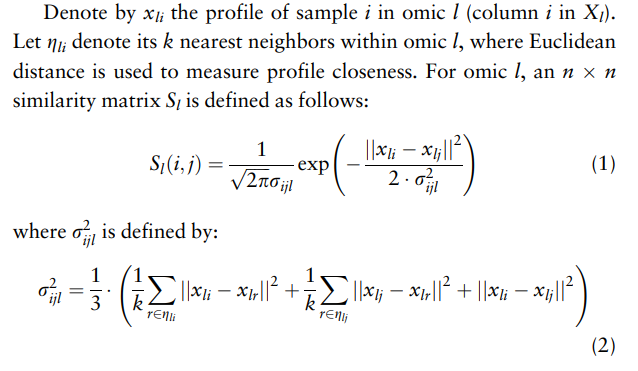

(Screenshot from the reference paper, page 3349)

In [221]:
from scipy.spatial.distance import cdist
def compute_similarity(X, k = 10):
    # to use cdist, we need numpy array as dtype. To reduce memory, we use np.asarray
    X = np.asarray(X, dtype = float)
    n = X.shape[0] # number of samples within the omic
    k = max(1, min(k, n-1))    # ensure valid k

    # compute Euclidean distance matrix
    D2 = cdist(X, X, metric = "sqeuclidean")
    D2_sorted = np.sort(D2, axis = 1)
    nn_idx = np.argsort(D2, axis=1)[:, 1:k+1]   # shape (n, k)
    knn_means = D2_sorted[:, 1:k+1].mean(axis = 1) # compute the k neighbor mean
    # compute sigma_{ijl}
    S = np.zeros_like(D2) # create a similarity matrix with the same dimension as D2
    for ii in range(n):
        for jj in range(n):
            sigma_sq = knn_means[ii] + knn_means[jj] + D2[ii,jj] 
            sigma_sq = sigma_sq / 3
            S[ii,jj] = np.exp( - D2[ii,jj]/(2 * sigma_sq + 1e-12) )  / ( np.sqrt(2 * np.pi * sigma_sq)  )

    return S,  nn_idx

k = 15
S_rna, knn_idx_rna  = compute_similarity(rna_union, k )
S_rppa, knn_idx_rppa = compute_similarity(rppa_union, k )

print("Similarity shapes:")
print("RNA :", S_rna.shape)
print("RPPA:", S_rppa.shape)

Similarity shapes:
RNA : (155, 155)
RPPA: (228, 228)


In [222]:
print(knn_idx_rna.shape)

(155, 15)


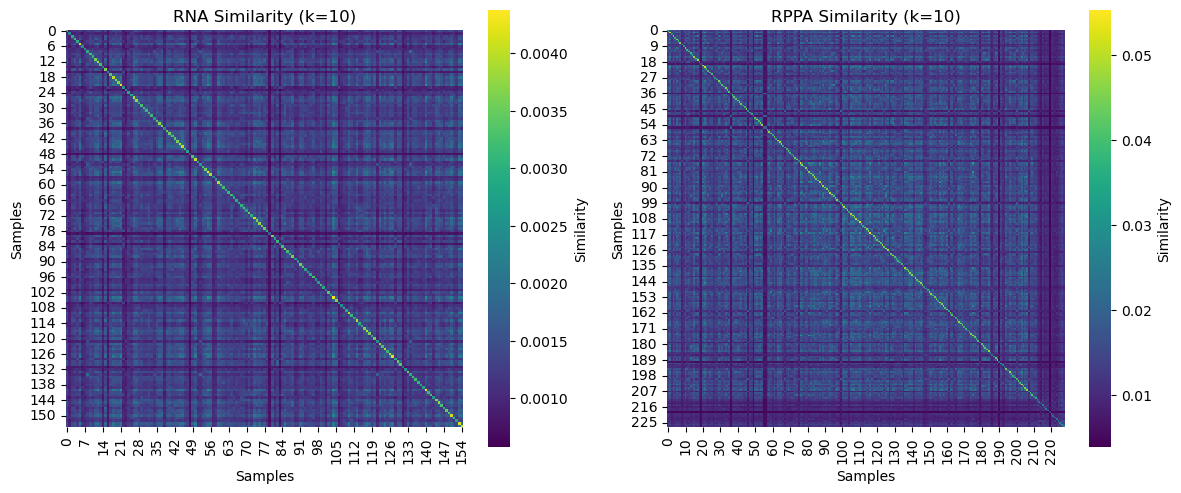

In [223]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create one figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))# RNA similarity heatmap

# RNA similarity heatmap
sns.heatmap(S_rna, ax = axes[0], cmap="viridis", square=True, cbar_kws={"label": "Similarity"})
axes[0].set_title("RNA Similarity (k=10)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Samples")


# RPPA similarity heatmap
sns.heatmap(S_rppa, ax = axes[1], cmap="viridis", square=True, cbar_kws={"label": "Similarity"})
axes[1].set_title("RPPA Similarity (k=10)")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Samples")

# adjust layout
plt.tight_layout()
plt.show()


Next we compute the relative similarity matrix RS_l

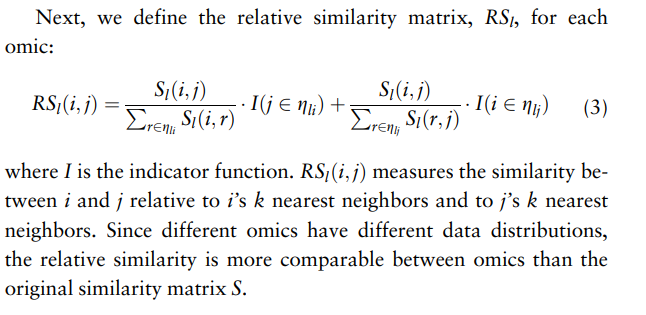

(Screenshot from the reference paper, page 3349)

In [224]:
def compute_relative_similarity(S, knn_idx, k=10):
    S = np.asarray(S, dtype = float)
    n = S.shape[0]
    k = max(1, min(k, n-1))

    RS = np.zeros_like(S)
    for ii in range(n):
        for jj in range(n):
            check_i_nn = int(np.isin(jj, knn_idx[ii,:]))
            check_j_nn = int(np.isin(ii, knn_idx[jj,:]))
            RS[ii,jj]   = check_i_nn * S[ii,jj]/np.sum(S[ii,knn_idx[ii]])
            RS[ii,jj]  += check_j_nn * S[ii,jj]/np.sum(S[knn_idx[jj],jj])
    
    return RS

    

# --- Build RS for each omic on its own sample set ---
RS_rna  = compute_relative_similarity(S_rna, knn_idx_rna, k)
RS_rppa = compute_relative_similarity(S_rppa, knn_idx_rppa, k)


In [225]:
RS_rna.shape
RS_rppa.shape

(228, 228)

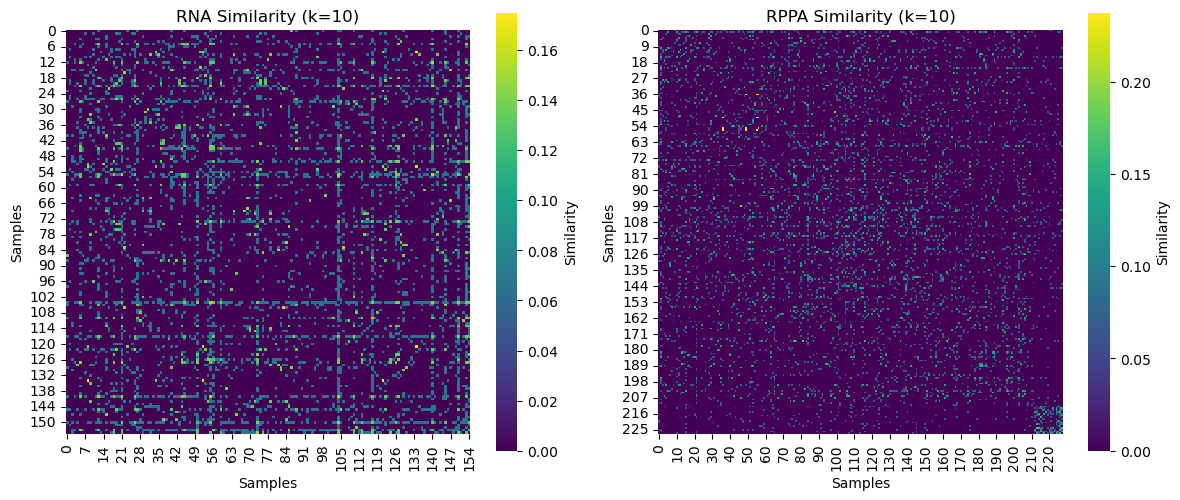

In [226]:
# Create one figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))# RNA similarity heatmap

# RNA similarity heatmap
sns.heatmap(RS_rna, ax = axes[0], cmap="viridis", square=True, cbar_kws={"label": "Similarity"})
axes[0].set_title("RNA Similarity (k=10)")
axes[0].set_xlabel("Samples")
axes[0].set_ylabel("Samples")


# RPPA similarity heatmap
sns.heatmap(RS_rppa, ax = axes[1], cmap="viridis", square=True, cbar_kws={"label": "Similarity"})
axes[1].set_title("RPPA Similarity (k=10)")
axes[1].set_xlabel("Samples")
axes[1].set_ylabel("Samples")

# adjust layout
plt.tight_layout()
plt.show()


Now compute the ARS ( the average relative similarity matrix ): 

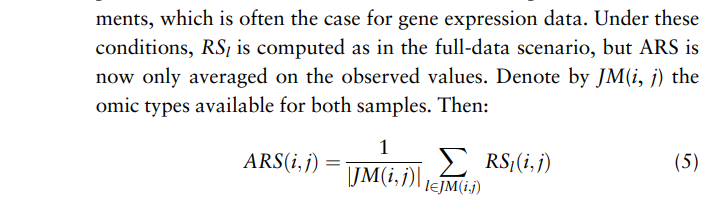

(Screenshot from the reference paper, page 3350)

In [227]:
def compute_ARS(rs_list, id_list):
    union_ids = sorted(set().union(*id_list))
    nU        = len(union_ids)
    pos_union = {sid:i  for i, sid in enumerate(union_ids)}
    ARS_sum = np.zeros((nU, nU), dtype=float)
    ARS_cnt = np.zeros((nU, nU), dtype=float)

    # --- accumulate RS_l where both samples exist ---
    for RS, ids in zip(rs_list, id_list):
        idx = np.array([pos_union[s] for s in ids])
        ARS_sum[np.ix_(idx, idx)] += RS
        ARS_cnt[np.ix_(idx, idx)] += 1.0
    # --- average only over observed omics ---
    ARS = np.divide(ARS_sum, ARS_cnt, out=np.zeros_like(ARS_sum), where=ARS_cnt>0)
    
    return ARS, union_ids

ARS, union_ids = compute_ARS(
    rs_list=[RS_rna, RS_rppa],
    id_list=[list(rna_union.index), list(rppa_union.index)]
)

print("ARS shape:", ARS.shape)


ARS shape: (308, 308)


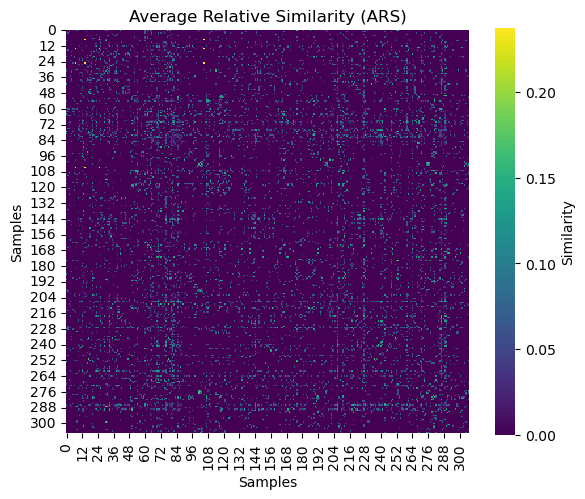

In [228]:
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(ARS, ax = ax, cmap="viridis", square=True, cbar_kws={"label": "Similarity"})
ax.set_title("Average Relative Similarity (ARS)")
ax.set_xlabel("Samples")
ax.set_ylabel("Samples")

plt.tight_layout()
plt.show()

After obtaining the ARS, we can carry out clustering to the union data. We consider two types of clustering methods: Spectral clustering and Diffusion map. The log rank test suggests K = 5 to 6 clusters is appropriate to do inference on ARS. 

First 10 eigenvalues:
 [0.     0.2243 0.3231 0.3549 0.3885 0.4132 0.4282 0.4386 0.4651 0.4885]


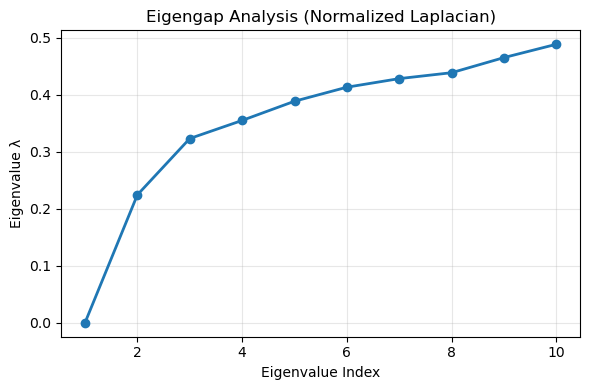

Suggested number of clusters (K): 1


In [229]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# --- Compute normalized Laplacian ---
# Degree matrix
d = ARS.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(d + 1e-12))
L = np.eye(len(ARS)) - D_inv_sqrt @ ARS @ D_inv_sqrt

# --- Compute smallest eigenvalues (ascending) ---
# eigh gives sorted ascending eigenvalues for symmetric matrices
eigvals, eigvecs = eigh(L)
print("First 10 eigenvalues:\n", np.round(eigvals[:10], 4))

# --- Plot eigengap ---
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), eigvals[:10], "o-", lw=2)
plt.title("Eigengap Analysis (Normalized Laplacian)")
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue λ")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gaps = np.diff(eigvals[:10])
K_opt = np.argmax(gaps) + 1  # +1 because diff reduces length by 1
print(f"Suggested number of clusters (K): {K_opt}")


In [238]:
from sklearn.cluster import SpectralClustering
import numpy as np

# Choose number of clusters K (you can tune via eigengap or domain knowledge)
K = 6

# Spectral clustering on ARS
model = SpectralClustering(
    n_clusters=K,
    affinity='precomputed',
    random_state=0
)
clusters = model.fit_predict(ARS)

# Attach cluster labels back to your sample index
import pandas as pd
cluster_df = pd.DataFrame({
    "PATIENT_ID": union_ids,
    "Cluster": clusters
})
print(cluster_df.head())


     PATIENT_ID  Cluster
0  TCGA-02-0003        1
1  TCGA-02-0011        3
2  TCGA-02-0014        3
3  TCGA-02-0047        0
4  TCGA-02-0055        0


c:\Users\Norman\miniconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


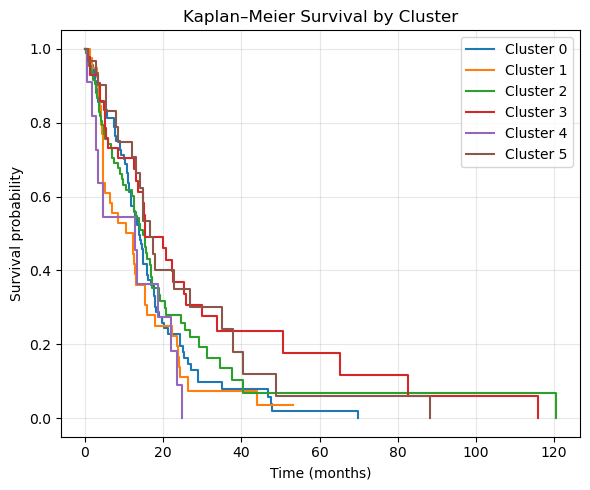

In [239]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

# Merge cluster assignments with survival table
df = pd.merge(cluster_df, clin_surv_union, on="PATIENT_ID", how="inner")
# Drop patients with missing survival info
df = df.dropna(subset=["OS_MONTHS", "OS_EVENT"]).copy()
df["OS_EVENT"] = df["OS_EVENT"].astype(int)

# Plot KM curves per cluster
kmf = KaplanMeierFitter()
plt.figure(figsize=(6,5))

for c in sorted(df["Cluster"].unique()):
    subset = df[df["Cluster"] == c]
    kmf.fit(subset["OS_MONTHS"], event_observed=subset["OS_EVENT"], label=f"Cluster {c}")
    kmf.plot(ci_show=False)

plt.title("Kaplan–Meier Survival by Cluster")
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




In [240]:
from lifelines.statistics import multivariate_logrank_test

# Multivariate log-rank test across all clusters
results = multivariate_logrank_test(
    event_durations=df["OS_MONTHS"],
    groups=df["Cluster"],
    event_observed=df["OS_EVENT"]
)
print("Global log-rank test p-value:", results.p_value)


Global log-rank test p-value: 0.03622536521767385


Eigenvalues: [0.833  0.7878 0.7546]
Embedding shape: (308, 3)


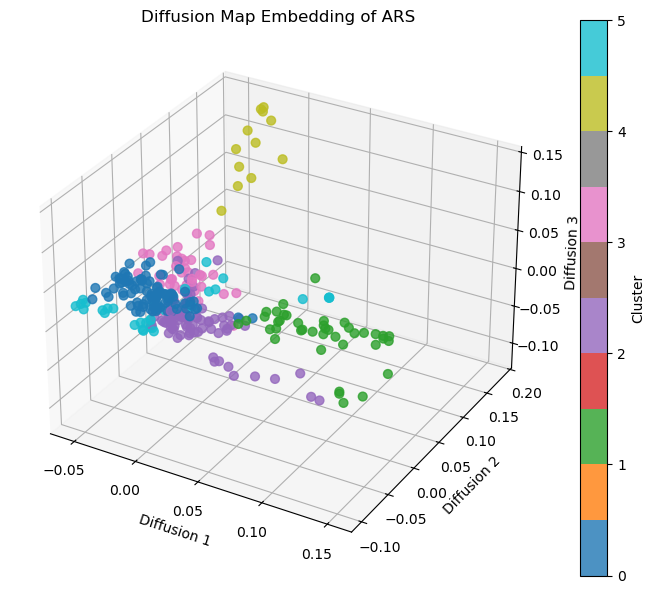

In [241]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

def diffusion_map_from_similarity(S, n_components=3, alpha=1.0):
    """
    Compute diffusion map embedding from a similarity matrix S (e.g. ARS).

    Parameters
    ----------
    S : array-like (n_samples, n_samples)
        Similarity / affinity matrix (symmetric, nonnegative)
    n_components : int
        Number of diffusion coordinates to return.
    alpha : float
        Normalization parameter (1 = symmetric normalization).

    Returns
    -------
    embedding : ndarray (n_samples, n_components)
    eigenvalues : ndarray (n_components,)
    """
    # --- 1. Normalize to Markov transition matrix ---
    S = np.asarray(S, dtype=float)
    n = S.shape[0]

    # Row degree (sum of similarities)
    d = S.sum(axis=1)
    D_alpha = np.power(d, -alpha)
    D_alpha[np.isinf(D_alpha)] = 0
    K = (D_alpha[:, None] * S) * D_alpha[None, :]

    # Normalize rows to sum to 1 (Markov transition)
    P = K / (K.sum(axis=1, keepdims=True) + 1e-12)

    # --- 2. Compute top eigenvectors of P ---
    vals, vecs = eigs(P, k=n_components + 1, which='LR')  # largest real parts
    vals = np.real(vals)
    vecs = np.real(vecs)

    # Sort by eigenvalue magnitude descending
    idx = np.argsort(-vals)
    vals, vecs = vals[idx], vecs[:, idx]

    # Skip the first trivial eigenvector (constant)
    embedding = vecs[:, 1:n_components+1] * vals[1:n_components+1]

    return embedding, vals[1:n_components+1]

# --- Compute diffusion embedding ---
Y, eigvals = diffusion_map_from_similarity(ARS, n_components=3)

print("Eigenvalues:", np.round(eigvals, 4))
print("Embedding shape:", Y.shape)

# --- Visualization (3D scatter) ---
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(Y[:,0], Y[:,1], Y[:,2], c=clusters, cmap="tab10", s=40, alpha=0.8)
ax.set_title("Diffusion Map Embedding of ARS")
ax.set_xlabel("Diffusion 1")
ax.set_ylabel("Diffusion 2")
ax.set_zlabel("Diffusion 3")
plt.colorbar(sc, label="Cluster")
plt.tight_layout()
plt.show()
